<a href="https://colab.research.google.com/github/sumandash509/AML_LAB/blob/main/AMLLAB4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

write to take a dataset consist of the following feature and three iteration apply the linear regression with a gradient descent technique to minimize the cost and perform the data visuallization to demonstrat the cost increasing toward the global minima

Student ID: ['S1' 'S2' 'S3']
x: [1. 2. 3.]
y: [2. 3. 4.]

Initial weight (w): 0.0
Initial bias (b): 0.0
Learning rate (alpha): 0.05

ITERATION 1

BEFORE UPDATE
w = 0.0
b = 0.0
Cost = 9.6667

Prediction Table Before Update:
Student ID   x  Actual y  Prediction Before  Error Before
        S1 1.0       2.0                0.0           2.0
        S2 2.0       3.0                0.0           3.0
        S3 3.0       4.0                0.0           4.0

COMPUTE GRADIENT
dw = -13.3333
db = -6.0

UPDATE PARAMETERS
Old w = 0.0
New w = 0.6667
Old b = 0.0
New b = 0.3

NEW PREDICTIONS
S1 => 0.9667
S2 => 1.6333
S3 => 2.3

UPDATED PREDICTION TABLE
Student ID   x  Actual y  Prediction Before  Prediction After  Error After
        S1 1.0       2.0                0.0          0.966667     1.033333
        S2 2.0       3.0                0.0          1.633333     1.366667
        S3 3.0       4.0                0.0          2.300000     1.700000

NEW COST
Cost Before = 9.6667
Cost After  = 1.9419

I

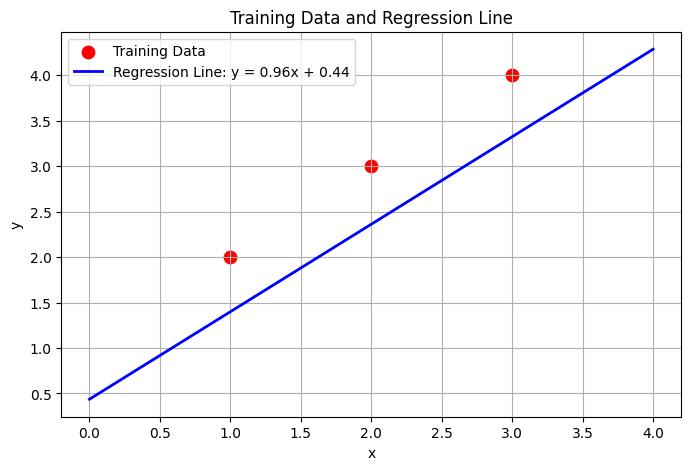

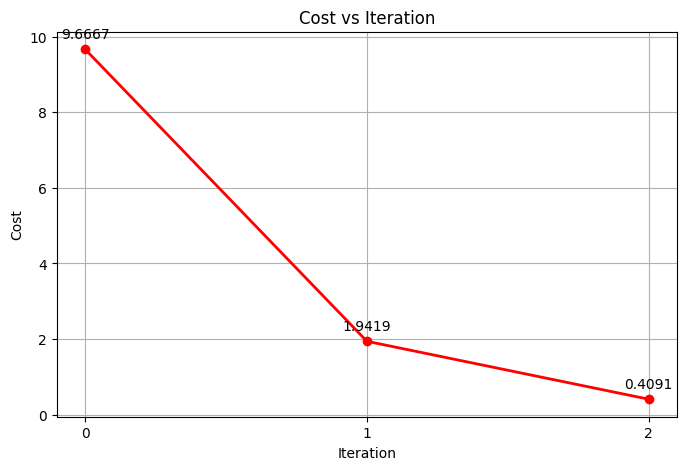

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# Dataset
# =====================================================

student_id = np.array(["S1", "S2", "S3"])

x = np.array([1, 2, 3], dtype=float)
y = np.array([2, 3, 4], dtype=float)

print("Student ID:", student_id)
print("x:", x)
print("y:", y)

# =====================================================
# Initial Parameters
# =====================================================

w = 0.0
b = 0.0

alpha = 0.05
iterations = 2

print("\nInitial weight (w):", w)
print("Initial bias (b):", b)
print("Learning rate (alpha):", alpha)

# =====================================================
# Prediction Function
# =====================================================

def predict(x, w, b):
    return w * x + b

# =====================================================
# Cost Function
# =====================================================

def compute_cost(y, y_pred):
    return np.sum((y - y_pred) ** 2) / len(y)

# =====================================================
# History
# =====================================================

cost_history = []
w_history = []
b_history = []

prediction_history = []

# =====================================================
# Training
# =====================================================

for i in range(iterations):

    print("\n" + "=" * 60)
    print(f"ITERATION {i + 1}")
    print("=" * 60)

    # --------------------------------
    # Current prediction
    # --------------------------------

    current_y_pred = predict(x, w, b)

    # Cost before update
    current_cost = compute_cost(y, current_y_pred)

    print("\nBEFORE UPDATE")
    print("w =", round(w, 4))
    print("b =", round(b, 4))
    print("Cost =", round(current_cost, 4))

    # --------------------------------
    # Prediction table BEFORE update
    # --------------------------------

    before_table = pd.DataFrame({
        "Student ID": student_id,
        "x": x,
        "Actual y": y,
        "Prediction Before": current_y_pred,
        "Error Before": y - current_y_pred
    })

    print("\nPrediction Table Before Update:")
    print(before_table.to_string(index=False))

    # --------------------------------
    # Compute gradient
    # --------------------------------

    dw = -2 * np.sum((y - current_y_pred) * x) / len(y)
    db = -2 * np.sum(y - current_y_pred) / len(y)

    print("\nCOMPUTE GRADIENT")
    print("dw =", round(dw, 4))
    print("db =", round(db, 4))

    # --------------------------------
    # Update parameters
    # --------------------------------

    old_w = w
    old_b = b

    w = w - alpha * dw
    b = b - alpha * db

    print("\nUPDATE PARAMETERS")
    print("Old w =", round(old_w, 4))
    print("New w =", round(w, 4))

    print("Old b =", round(old_b, 4))
    print("New b =", round(b, 4))

    # --------------------------------
    # New prediction
    # --------------------------------

    new_y_pred = predict(x, w, b)

    print("\nNEW PREDICTIONS")

    for j in range(len(x)):
        print(
            student_id[j],
            "=>",
            round(new_y_pred[j], 4)
        )

    # --------------------------------
    # Updated prediction table
    # --------------------------------

    prediction_table = pd.DataFrame({
        "Student ID": student_id,
        "x": x,
        "Actual y": y,
        "Prediction Before": current_y_pred,
        "Prediction After": new_y_pred,
        "Error After": y - new_y_pred
    })

    print("\nUPDATED PREDICTION TABLE")
    print(prediction_table.to_string(index=False))

    # --------------------------------
    # New cost
    # --------------------------------

    new_cost = compute_cost(y, new_y_pred)

    print("\nNEW COST")
    print("Cost Before =", round(current_cost, 4))
    print("Cost After  =", round(new_cost, 4))

    # --------------------------------
    # Save history
    # --------------------------------

    cost_history.append(new_cost)
    w_history.append(w)
    b_history.append(b)

    prediction_history.append(prediction_table.copy())


# =====================================================
# Training Summary
# =====================================================

print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)

training_summary_df = pd.DataFrame({
    "Iteration": range(1, iterations + 1),
    "Weight (w)": w_history,
    "Bias (b)": b_history,
    "Cost": cost_history
})

print(training_summary_df.to_string(index=False))


# =====================================================
# GRAPH 1: Training Data and Regression Line
# =====================================================

plt.figure(figsize=(8, 5))

# Actual training data
plt.scatter(
    x,
    y,
    color="red",
    s=80,
    label="Training Data"
)

# Regression line
x_line = np.linspace(0, 4, 100)
y_line = w * x_line + b

plt.plot(
    x_line,
    y_line,
    color="blue",
    linewidth=2,
    label=f"Regression Line: y = {w:.2f}x + {b:.2f}"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Training Data and Regression Line")

plt.legend()
plt.grid(True)

plt.show()


# =====================================================
# GRAPH 2: Cost vs Iteration
# =====================================================

# Calculate initial cost before training
initial_y_pred = predict(x, 0.0, 0.0)
initial_cost = compute_cost(y, initial_y_pred)

# Include initial cost at iteration 0
cost_values = [initial_cost] + cost_history
iteration_values = range(0, iterations + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    iteration_values,
    cost_values,
    marker="o",
    color="red",
    linewidth=2
)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Iteration")

plt.xticks(iteration_values)
plt.grid(True)

# Display cost values
for i, cost in zip(iteration_values, cost_values):
    plt.annotate(
        f"{cost:.4f}",
        (i, cost),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

plt.show()